# Model 2 - Decision Tree

This notebook covers **Stage 6 (model development)** and **Stage 7 (tuning)** for the Decision Tree model.
The results are saved to `results/` and compared with the other three models in `Final_Model_Comparison.ipynb`.

**Common rules (same in all four model notebooks, so the comparison is fair):**
- Same training data: `data/train_processed.csv` (the test set is **not** used here)
- Same validation: Stratified 5-Fold Cross-Validation, `random_state=42`
- Same main metric: **Macro F1**

## 1. Why Decision Tree?
- A Decision Tree learns **if-then rules**, for example *"if carrier = X and month is in winter and arr_flights is high → High Risk"*.
- It can learn **non-linear** relationships and **combinations** of features, which Logistic Regression cannot.
- The rules are easy to explain to non-technical stakeholders.
- It does not need scaled features.
- **Weakness:** without limits it keeps splitting until it memorises the training data (overfitting).

## 2. Load the Training Data

In [1]:
import json
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, recall_score
from sklearn.tree import DecisionTreeClassifier

# Training data created in Stage 4 (already cleaned, encoded and scaled)
train = pd.read_csv("data/train_processed.csv")

# X = input features, y = target (0 = Low, 1 = Moderate, 2 = High Risk)
X_train = train.drop(columns=["delay_risk_category"])
y_train = train["delay_risk_category"]

print("X_train:", X_train.shape)

X_train: (136978, 29)


## 3. Validation Strategy and Metrics
**Stratified 5-Fold Cross-Validation:** the training data is split into 5 parts. The model is trained on 4 parts and
tested on the 5th, five times, and the scores are averaged. *Stratified* keeps the Low / Moderate / High ratio the
same in every part, which matters because the classes are imbalanced (41% / 37% / 22%).

**Main metric: Macro F1.** It gives the three classes equal importance, so the smaller but most important
**High Risk** class is not ignored. Accuracy, precision and recall are also reported.

In [2]:
# Same folds in all four model notebooks
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics calculated in every fold
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

## 4. Baseline Model (Stage 6)
Default settings: the tree can grow until every leaf is pure (no depth limit).

In [3]:
baseline_model = DecisionTreeClassifier(random_state=42)

start = time.time()
# return_train_score=True also gives the training score, to check for overfitting
scores = cross_validate(baseline_model, X_train, y_train, cv=cv, scoring=scoring,
                        return_train_score=True, n_jobs=-1)
cv_time = time.time() - start

baseline = {
    "Accuracy": scores["test_accuracy"].mean(),
    "Precision": scores["test_precision"].mean(),
    "Recall": scores["test_recall"].mean(),
    "F1 (macro)": scores["test_f1"].mean(),
    "F1 std": scores["test_f1"].std(),       # small std = stable model
    "Train F1": scores["train_f1"].mean(),   # much higher than F1 = overfitting
    "CV time (s)": cv_time,
}
pd.Series(baseline).round(4)

Accuracy       0.5624
Precision      0.5511
Recall         0.5511
F1 (macro)     0.5511
F1 std         0.0037
Train F1       0.9988
CV time (s)    6.1882
dtype: float64

## 5. Confusion Matrix (Baseline)
`cross_val_predict` gives a prediction for every training record, made by a model that did **not** see that
record during training (the same 5 folds as above).

High Risk recall: 0.503


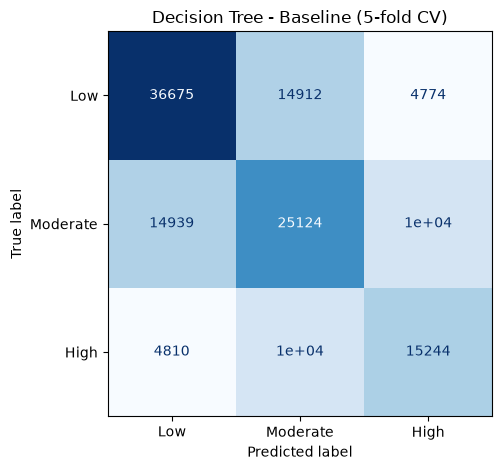

In [4]:
y_pred = cross_val_predict(baseline_model, X_train, y_train, cv=cv, n_jobs=-1)

# How many of the real High Risk cases (label 2) the model found
high_risk_recall = recall_score(y_train, y_pred, labels=[2], average="macro")
print(f"High Risk recall: {high_risk_recall:.3f}")

ConfusionMatrixDisplay.from_predictions(y_train, y_pred, display_labels=["Low", "Moderate", "High"],
                                        cmap="Blues", colorbar=False)
plt.title("Decision Tree - Baseline (5-fold CV)")
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning (Stage 7)
**Search strategy: GridSearchCV.** It tries **every combination** of the settings below with the same 5-fold CV
and keeps the one with the best Macro F1. A grid search fits here because only a few important settings are tuned,
so trying all combinations is still fast enough.

| Setting | Values tried | What it controls |
|---|---|---|
| `max_depth` | 5, 10, 15, 20 | How many levels of questions the tree can ask. Limits overfitting |
| `min_samples_leaf` | 1, 20, 50 | Minimum records in a final leaf. Stops rules that are based on only a few records |

In [5]:
param_grid = {"max_depth": [5, 10, 15, 20], "min_samples_leaf": [1, 20, 50]}

start = time.time()
search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
search.fit(X_train, y_train)

print("Best settings:", search.best_params_)
print(f"Best Macro F1: {search.best_score_:.4f}  ({time.time() - start:.0f}s)")

Best settings: {'max_depth': 20, 'min_samples_leaf': 20}
Best Macro F1: 0.5848  (16s)


In [6]:
# Score of every combination that was tried, best first
grid_results = pd.DataFrame(search.cv_results_)[["params", "mean_test_score", "std_test_score"]]
grid_results.columns = ["Settings", "Macro F1", "Std"]
grid_results.sort_values("Macro F1", ascending=False).round(4)

,Settings,Macro F1,Std
10,"{'max_depth': 20, 'min_samples_leaf': 20}",0.5848,0.0021
11,"{'max_depth': 20, 'min_samples_leaf': 50}",0.5824,0.0020
7,"{'max_depth': 15, 'min_samples_leaf': 20}",0.5794,0.0020
8,"{'max_depth': 15, 'min_samples_leaf': 50}",0.5768,0.0021
6,"{'max_depth': 15, 'min_samples_leaf': 1}",0.5738,0.0025
9,"{'max_depth': 20, 'min_samples_leaf': 1}",0.5691,0.0039
4,"{'max_depth': 10, 'min_samples_leaf': 20}",0.5419,0.0071
3,"{'max_depth': 10, 'min_samples_leaf': 1}",0.5417,0.0070
5,"{'max_depth': 10, 'min_samples_leaf': 50}",0.5401,0.0070
2,"{'max_depth': 5, 'min_samples_leaf': 50}",0.4256,0.0255


## 7. Baseline vs Tuned

Baseline F1    0.5511
Tuned F1       0.5848
dtype: float64
Improvement: +0.0337


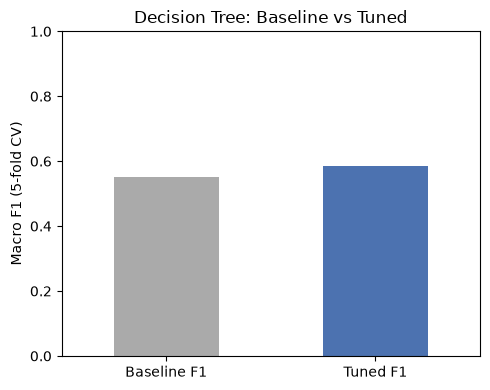

In [7]:
compare = pd.Series({
    "Baseline F1": baseline["F1 (macro)"],
    "Tuned F1": search.best_score_,
})
print(compare.round(4))
print(f"Improvement: {compare['Tuned F1'] - compare['Baseline F1']:+.4f}")

compare.plot(kind="bar", color=["#AAAAAA", "#4C72B0"], rot=0, figsize=(5, 4))
plt.title("Decision Tree: Baseline vs Tuned")
plt.ylabel("Macro F1 (5-fold CV)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Observations
**Results**

| | Macro F1 | Train F1 | High Risk Recall |
|---|---|---|---|
| Baseline (no limits) | 0.551 | 0.999 | 0.503 |
| Tuned (`max_depth=20`, `min_samples_leaf=20`) | **0.585** | - | - |

- **The baseline tree overfits badly.** It scores 0.999 on the training data but only 0.551 on validation data. It has memorised the training records instead of learning general rules.
- **Tuning gave the biggest improvement of all four models (+0.034).** Limiting the depth to 20 and requiring at least 20 records per leaf forces the tree to learn rules that hold for many records, so it generalises better.
- **Why it beats Logistic Regression:** a tree can learn feature combinations (carrier + airport + season), which is how delay risk actually works.
- **Why it is behind Random Forest:** a single tree is unstable. A small change in the data can change the whole tree. Random Forest fixes this by averaging many trees.

## 9. Save the Results
These results are loaded by `Final_Model_Comparison.ipynb` to compare all four models.

In [8]:
import os
os.makedirs("results", exist_ok=True)

result_row = {
    "Model": "Decision Tree",
    **{f"Baseline {k}": v for k, v in baseline.items()},
    "Baseline High Risk Recall": high_risk_recall,
    "Tuned F1": search.best_score_,
    "Best Params": json.dumps(search.best_params_),   # the final notebook rebuilds the model from these
}
pd.DataFrame([result_row]).to_csv("results/decision_tree_results.csv", index=False)
print("Saved results/decision_tree_results.csv")

Saved results/decision_tree_results.csv
